# Demo 3: Neo4j – Gráf adatbázis

Gráf adatbázisok a gyakorlatban:
- Csomópontok (Nodes) és kapcsolatok (Relationships) létrehozása
- Cypher lekérdezési nyelv alapjai
- Ajánlórendszer: kollaboratív szűrés gráf alapon
- Útvonalkereső lekérdezések
- Vizualizáció networkx-szel

**Infrastruktúra:** Neo4j 5, neo4j Python driver
**Neo4j Browser:** http://localhost:7474 (user: neo4j, password: password123)

In [1]:
!pip install -q neo4j pandas matplotlib networkx faker

from neo4j import GraphDatabase
import pandas as pd
import random
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from faker import Faker

fake = Faker("hu_HU")
Faker.seed(42)
random.seed(42)

driver = GraphDatabase.driver("bolt://neo4j:7687", auth=("neo4j", "password123"))

# Test connection
with driver.session() as session:
    result = session.run("RETURN 'Neo4j kapcsolat OK' AS msg")
    print(result.single()["msg"])

Neo4j kapcsolat OK


## 1. Gráf létrehozása – Csomópontok és Kapcsolatok

Az e-commerce gráf felépítése:
- **Customer** csomópontok: vásárlók
- **Product** csomópontok: termékek
- **Category** csomópontok: termékkategóriák
- **[:BOUGHT]** kapcsolat: Customer → Product (qty, date, amount tulajdonságokkal)
- **[:IN_CATEGORY]** kapcsolat: Product → Category

In [2]:
CATEGORIES = ["Elektronika", "Ruházat", "Élelmiszer", "Sport", "Könyv"]

with driver.session() as session:
    # Clear database
    session.run("MATCH (n) DETACH DELETE n")
    
    # Create Category nodes
    for cat in CATEGORIES:
        session.run("CREATE (:Category {name: $name})", name=cat)
    
    # Create Product nodes
    for i in range(1, 51):
        cat = random.choice(CATEGORIES)
        session.run("""
            CREATE (:Product {
                product_id: $pid, name: $name,
                category: $cat, price: $price
            })
        """, pid=i, name=f"Termék-{i:03d}",
             cat=cat, price=round(random.uniform(1000, 50000), -2))
    
    # Link products to categories
    session.run("""
        MATCH (p:Product), (c:Category {name: p.category})
        CREATE (p)-[:IN_CATEGORY]->(c)
    """)
    
    # Create Customer nodes
    for i in range(1, 51):
        session.run("""
            CREATE (:Customer {
                customer_id: $cid, name: $name, segment: $seg
            })
        """, cid=i, name=fake.name(),
             seg=random.choice(["standard","standard","gold","premium"]))
    
    # Create BOUGHT relationships
    bought_count = 0
    for customer_id in range(1, 51):
        n_bought = random.randint(2, 8)
        products_bought = random.sample(range(1, 51), n_bought)
        for product_id in products_bought:
            session.run("""
                MATCH (c:Customer {customer_id: $cid}),
                      (p:Product    {product_id:  $pid})
                CREATE (c)-[:BOUGHT {
                    quantity: $qty,
                    amount:   $amount,
                    date:     $date
                }]->(p)
            """, cid=customer_id, pid=product_id,
                 qty=random.randint(1,3),
                 amount=round(random.uniform(2000,40000),-2),
                 date=fake.date_between(start_date="-2y").isoformat())
            bought_count += 1
    
    # Statistics
    n_customers = session.run("MATCH (c:Customer) RETURN count(c) AS n").single()["n"]
    n_products  = session.run("MATCH (p:Product)  RETURN count(p) AS n").single()["n"]
    n_categories= session.run("MATCH (c:Category) RETURN count(c) AS n").single()["n"]
    n_bought    = session.run("MATCH ()-[r:BOUGHT]->() RETURN count(r) AS n").single()["n"]
    
    print("✓ Gráf létrehozva:")
    print(f"  Customer csomópontok:  {n_customers}")
    print(f"  Product csomópontok:   {n_products}")
    print(f"  Category csomópontok:  {n_categories}")
    print(f"  BOUGHT kapcsolatok:    {n_bought}")

✓ Gráf létrehozva:
  Customer csomópontok:  50
  Product csomópontok:   50
  Category csomópontok:  5
  BOUGHT kapcsolatok:    268


## 2. Alapvető Cypher lekérdezések

Cypher: deklaratív gráf lekérdezési nyelv.
`MATCH (c:Customer)-[:BOUGHT]->(p:Product)` – mintaillesztés a gráfban.

In [3]:
# Query 1: Top 5 most bought products
with driver.session() as session:
    result = session.run("""
        MATCH (c:Customer)-[b:BOUGHT]->(p:Product)
        RETURN p.name AS product, p.category AS category,
               COUNT(b) AS buyer_count, SUM(b.amount) AS total_revenue
        ORDER BY buyer_count DESC
        LIMIT 5
    """)
    df1 = pd.DataFrame([dict(r) for r in result])

print("=== Top 5 legtöbbet vásárolt termék ===\n")
print(df1.to_string(index=False))

# Query 2: Customers who spent the most
with driver.session() as session:
    result = session.run("""
        MATCH (c:Customer)-[b:BOUGHT]->(p:Product)
        RETURN c.name AS customer, c.segment AS segment,
               COUNT(b) AS orders, SUM(b.amount) AS total_spent
        ORDER BY total_spent DESC
        LIMIT 5
    """)
    df2 = pd.DataFrame([dict(r) for r in result])

print("\n=== Top 5 vásárló forgalom szerint ===\n")
print(df2.to_string(index=False))

=== Top 5 legtöbbet vásárolt termék ===

   product   category  buyer_count  total_revenue
Termék-048      Könyv            9       165800.0
Termék-017 Élelmiszer            8       144500.0
Termék-037 Élelmiszer            8       189800.0
Termék-028      Sport            8       134600.0
Termék-025    Ruházat            8       161100.0

=== Top 5 vásárló forgalom szerint ===

              customer  segment  orders  total_spent
   Juhász Vincze Tímea  premium       8     209200.0
       M. Katona Beáta standard       8     203000.0
  Szabó Sárközi Mónika standard       8     194700.0
Dr. Németh Illés Csaba standard       8     192400.0
     Dr. Deák Marianna     gold       7     188400.0


## 3. Ajánlórendszer – Kollaboratív szűrés Cypher-rel

"Akik X terméket vásárolták, Y-t is megvették" – klasszikus ajánló algoritmus.

SQL-ben: `SELECT p2.name FROM orders o1 JOIN orders o2 ON o1.customer_id=o2.customer_id JOIN products p2...`
(2 self-join + szűrés)

Cypher-ben: 3 sor, olvasható, természetes gráf bejárás.

In [4]:
target_product_id = 1

with driver.session() as session:
    # Get target product name
    target_name = session.run(
        "MATCH (p:Product {product_id: $pid}) RETURN p.name",
        pid=target_product_id
    ).single()[0]
    
    # Collaborative filtering: customers who bought target also bought...
    result = session.run("""
        MATCH (target:Product {product_id: $pid})
        MATCH (c:Customer)-[:BOUGHT]->(target)
        MATCH (c)-[:BOUGHT]->(other:Product)
        WHERE other.product_id <> $pid
        RETURN other.name AS recommended, other.category AS category,
               COUNT(DISTINCT c) AS co_buyers
        ORDER BY co_buyers DESC
        LIMIT 5
    """, pid=target_product_id)
    
    df_rec = pd.DataFrame([dict(r) for r in result])

print(f"=== Ajánlások: '{target_name}' vásárlói ezeket is megvették ===\n")
print(df_rec.to_string(index=False))
print(f"\n✓ Cypher query: 3 MATCH sor vs SQL: 2 self-JOIN + subquery")

=== Ajánlások: 'Termék-001' vásárlói ezeket is megvették ===

recommended    category  co_buyers
 Termék-011 Elektronika          2
 Termék-022       Könyv          2
 Termék-036       Könyv          2
 Termék-027 Elektronika          2
 Termék-005       Sport          2

✓ Cypher query: 3 MATCH sor vs SQL: 2 self-JOIN + subquery


## 4. Kategória-szintű elemzés és útvonalkeresés

In [5]:
# Category cross-buy analysis
with driver.session() as session:
    result = session.run("""
        MATCH (c:Customer)-[:BOUGHT]->(p1:Product)-[:IN_CATEGORY]->(cat1:Category)
        MATCH (c)-[:BOUGHT]->(p2:Product)-[:IN_CATEGORY]->(cat2:Category)
        WHERE cat1.name < cat2.name
        RETURN cat1.name AS category_a, cat2.name AS category_b,
               COUNT(DISTINCT c) AS common_buyers
        ORDER BY common_buyers DESC
        LIMIT 8
    """)
    df_cross = pd.DataFrame([dict(r) for r in result])

print("=== Kategória kereszt-vásárlások (ki vett mindkét kategóriából) ===\n")
print(df_cross.to_string(index=False))

# Customers who bought from ALL categories
with driver.session() as session:
    result = session.run("""
        MATCH (c:Customer)-[:BOUGHT]->(p:Product)-[:IN_CATEGORY]->(cat:Category)
        WITH c, COUNT(DISTINCT cat) AS category_count
        WHERE category_count >= 3
        RETURN c.name AS customer, c.segment AS segment, category_count
        ORDER BY category_count DESC
        LIMIT 5
    """)
    df_multi = pd.DataFrame([dict(r) for r in result])

print("\n=== Ügyfelek 3+ kategóriában vásároltak ===\n")
print(df_multi.to_string(index=False))

=== Kategória kereszt-vásárlások (ki vett mindkét kategóriából) ===

 category_a category_b  common_buyers
Elektronika      Könyv             26
      Könyv Élelmiszer             26
Elektronika Élelmiszer             24
      Sport Élelmiszer             24
      Könyv    Ruházat             23
      Könyv      Sport             23
Elektronika      Sport             22
    Ruházat Élelmiszer             21

=== Ügyfelek 3+ kategóriában vásároltak ===

           customer  segment  category_count
        N. Kis Irma standard               5
   Hegedüs Á. Gábor standard               5
Juhász Vincze Tímea  premium               5
    M. Katona Beáta standard               5
Dr. Boros Bernadett standard               5


## 5. Gráf vizualizáció – networkx + matplotlib

A Neo4j adatait betöltjük egy networkx gráfba és vizualizáljuk.
(Csak 10 ügyfél + top 15 termék a jobb olvashatóság kedvéért)

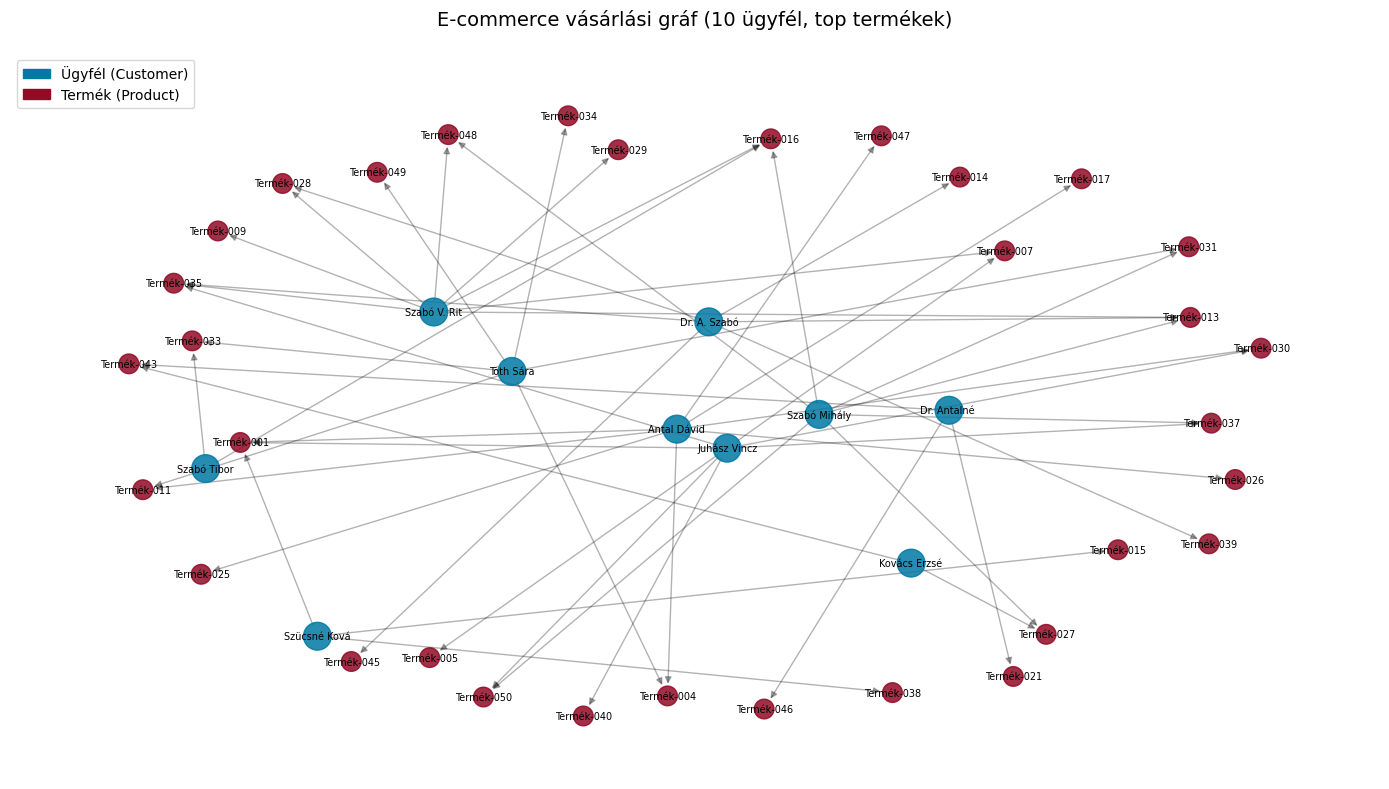

✓ Gráf mentve: /home/jovyan/work/graph_visualization.png
✓ Demo 3 vége – Neo4j gráf adatbázis befejezve!


In [6]:
G = nx.DiGraph()
node_colors = {}
node_sizes  = {}

# Load a subgraph: first 10 customers + their top products
with driver.session() as session:
    result = session.run("""
        MATCH (c:Customer)-[b:BOUGHT]->(p:Product)
        WHERE c.customer_id <= 10
        RETURN c.name AS customer, p.name AS product,
               p.category AS category, b.quantity AS qty
        LIMIT 60
    """)
    for row in result:
        cname = row["customer"][:12]
        pname = row["product"]
        G.add_node(cname, type="customer")
        G.add_node(pname, type="product")
        G.add_edge(cname, pname, weight=row["qty"])
        node_colors[cname] = "#0079A4"   # BME_TEAL
        node_colors[pname] = "#910A26"   # BME_MAROON

colors = [node_colors.get(n, "#888888") for n in G.nodes()]
sizes  = [400 if G.nodes[n].get("type") == "customer" else 200 for n in G.nodes()]

fig, ax = plt.subplots(1, 1, figsize=(14, 8))
pos = nx.spring_layout(G, k=1.5, seed=42)
nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=sizes, alpha=0.85, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=7, ax=ax)
nx.draw_networkx_edges(G, pos, alpha=0.3, arrows=True, arrowsize=10, ax=ax)

customer_patch = mpatches.Patch(color="#0079A4", label="Ügyfél (Customer)")
product_patch  = mpatches.Patch(color="#910A26", label="Termék (Product)")
ax.legend(handles=[customer_patch, product_patch], loc="upper left")
ax.set_title("E-commerce vásárlási gráf (10 ügyfél, top termékek)", fontsize=14, pad=20)
ax.axis("off")
plt.tight_layout()
plt.savefig("/home/jovyan/work/graph_visualization.png", dpi=100, bbox_inches="tight")
plt.show()
print("✓ Gráf mentve: /home/jovyan/work/graph_visualization.png")
print("✓ Demo 3 vége – Neo4j gráf adatbázis befejezve!")
driver.close()